# YouBike Rental Forecasting around NTU and Gongguan
## Starter notebook, version 3
Work in your existing group (maximum four members). Submit one executed notebook per group. All members receive the same grade. Read `Assignment_Guide_EN.md` first.

Complete the **TODO** functions and the four short answers. Loading, encoding, training loops, logistic regression, plotting, and evaluation are supplied. Unfinished TODO functions intentionally raise `NotImplementedError`.

At forecast time t, predict rentals in [t, t+1 hour). All features describe information available before that hour. The same station appears in all chronological splits because the task predicts future activity at known stations.

## Environment and reproducibility

Recommended tested runtime: **Python 3.12.14, NumPy 2.3.5, pandas 2.2.3, matplotlib 3.10.8, scikit-learn 1.8.0**. No GPU is required.

Recommended local setup (after installing Python 3.12.14):

```bash
python -m venv .venv
# macOS / Linux:
source .venv/bin/activate
# Windows PowerShell (instead of the line above):
# .venv\Scripts\Activate.ps1
python -m pip install -r requirements.txt
python -m pip install jupyterlab
python -m jupyter lab
```

`requirements.txt` fixes the four scientific-package versions; it does not install Python or lock all transitive dependencies. JupyterLab is a notebook interface and is installed separately. Another environment, including Colab, is allowed. Do not change a working Colab runtime merely to match package versions. **Every group must execute the final environment cell and retain its Python version, key package versions, and complete `pip list` output.** No separate environment file is required. Small numerical differences alone are not penalized.

## Submission

Submit **one executed notebook named `Group_01_YouBike.ipynb`**, replacing `01` with your group number. Preserve all code, figures, tables, four short English answers, contribution statements, and environment output. Do not submit the CSV, ZIP, or an exported Python script. Use the supplied CSV unchanged. Keep function names, signatures, and the provided experiment sections so TAs can rerun your work. Implement the six required functions using NumPy directly, without additional custom helper functions. Do not remove reference cells or the environment cell.

The basic self-checks are formative, not the complete marking tests. TAs check core functions using independent numerical tests and review the remaining experiments and explanations. Submitted output text alone is not evidence of correctness. A run failure is flagged for review and does not automatically assign a zero to the entire assignment.



In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay)
try:
    from IPython.display import display
except ImportError:
    display = print
SEED = 42
np.random.seed(SEED)


## 1. Load and prepare the data (15%)
Keep the CSV beside this notebook. In Colab, upload it when prompted. Filter to `model_ready == 1`. The first 24 hours per station are excluded because their history is incomplete. Audit columns and targets are never model inputs.

In [2]:
csv_path = Path("youbike_hourly_english.csv")
if not csv_path.exists():
    github_url = "https://raw.githubusercontent.com/nhatanhpico/youbike-demand-prediction/main/youbike_hourly_english.csv"
    try:
        import urllib.request
        print("Downloading youbike_hourly_english.csv from repository...")
        urllib.request.urlretrieve(github_url, csv_path)
        print("Download complete.")
    except Exception:
        try:
            from google.colab import files
            print("Please upload youbike_hourly_english.csv:")
            files.upload()
        except ImportError:
            raise FileNotFoundError("Place youbike_hourly_english.csv beside this notebook.")
data = pd.read_csv(csv_path)
data["forecast_time"] = pd.to_datetime(data["forecast_time"])
data = data.loc[data["model_ready"].eq(1)].sort_values(
    ["forecast_time", "station_id"]).reset_index(drop=True)
parts = {s: data.loc[data["split"].eq(s)].reset_index(drop=True)
         for s in ["train", "validation", "test"]}
display(data.head())
display(data.groupby("split", sort=False).size().rename("rows"))

numeric_features = ["hour", "day_of_week", "is_weekend", "rentals_previous_hour",
    "rentals_same_hour_previous_day", "rentals_mean_previous_24h"]
station_vocabulary = [f"S{i:02d}" for i in range(1, 9)]
def encode(frame):
    numeric = frame[numeric_features].to_numpy(dtype=float)
    # Omit S01 as the reference category. Vocabulary is defined in advance.
    stations = np.column_stack([frame["station_id"].eq(s).to_numpy(dtype=float)
                                for s in station_vocabulary[1:]])
    return np.column_stack([numeric, stations])
X_raw = {s: encode(frame) for s, frame in parts.items()}
y_reg = {s: f["target_rentals_next_hour"].to_numpy(dtype=float)
         for s, f in parts.items()}
y_cls = {s: f["target_high_demand"].to_numpy(dtype=int)
         for s, f in parts.items()}


,forecast_time,station_id,station_name,hour,day_of_week,is_weekend,rentals_previous_hour,rentals_same_hour_previous_day,rentals_mean_previous_24h,target_rentals_next_hour,high_demand_threshold,target_high_demand,split,target_zero_assumed,station_day_has_records,city_hour_has_records,model_ready
0,2025-09-02 00:00:00+08:00,S01,MRT Gongguan Station (Exit 2),0,1,0,41.0,13.0,77.125000,24,116.0,0,train,0,1,1,1
1,2025-09-02 00:00:00+08:00,S02,MRT Gongguan Station (Exit 3),0,1,0,32.0,7.0,50.833333,15,82.0,0,train,0,1,1,1
2,2025-09-02 00:00:00+08:00,S03,NTU First Student Activity Center (Southwest),0,1,0,2.0,4.0,51.750000,2,54.0,0,train,0,1,1,1
3,2025-09-02 00:00:00+08:00,S04,NTU Xiaofu Building (East),0,1,0,16.0,0.0,45.333333,2,35.0,0,train,0,1,1,1
4,2025-09-02 00:00:00+08:00,S05,NTU Male Dormitory 1 (Front),0,1,0,4.0,4.0,38.333333,4,33.0,0,train,0,1,1,1


split
train         11520
validation     2880
test           2880
Name: rows, dtype: int64

**TODO A:** Compute the mean and standard deviation of each feature using training rows only. Use population standard deviation (`ddof=0`). Replace zero standard deviations with 1. Return the fitted mean and scale, then transform every split using these same arrays. Each feature matrix has shape (N, D).

In [3]:
def fit_standardizer(X_train):
    mean = np.mean(X_train, axis=0)
    scale = np.std(X_train, axis=0, ddof=0)
    scale = np.where(scale == 0.0, 1.0, scale)
    return mean, scale

def apply_standardizer(X, mean, scale):
    return (X - mean) / scale

feature_mean, feature_scale = fit_standardizer(X_raw["train"])
X = {s: apply_standardizer(a, feature_mean, feature_scale)
     for s, a in X_raw.items()}
assert np.isfinite(X["train"]).all()
print("Training shape:", X["train"].shape)
print("Maximum absolute training feature mean:", np.abs(X["train"].mean(axis=0)).max())


Training shape: (11520, 13)
Maximum absolute training feature mean: 3.254572537395954e-15


## 2. Linear regression with gradient descent (30%)
**TODO B–E:** Implement prediction, MSE, gradients, and one parameter update. Use a one-dimensional target of shape (N,), weights of shape (D,), and a scalar bias. For MSE = mean((prediction − target)²), remember the factor of 2 in its gradients. Do not call a regression estimator for these TODOs. The training loop is provided.

In [4]:
def linear_predict(X, w, b):
    return X @ w + b

def mse_loss(y, prediction):
    return np.mean((prediction - y) ** 2)

def linear_gradients(X, y, w, b):
    prediction = linear_predict(X, w, b)
    error = prediction - y
    grad_w = (2.0 / len(y)) * (X.T @ error)
    grad_b = 2.0 * np.mean(error)
    return grad_w, grad_b

def gradient_step(w, b, grad_w, grad_b, learning_rate):
    w_new = w - learning_rate * grad_w
    b_new = b - learning_rate * grad_b
    return w_new, b_new

def train_linear(X_train, y_train, learning_rate, steps=1500):
    w, b = np.zeros(X_train.shape[1]), 0.0
    losses = []
    for step in range(steps):
        prediction = linear_predict(X_train, w, b)
        loss = float(mse_loss(y_train, prediction))
        if not np.isfinite(loss) or loss > 1e15:
            return {"w": w, "b": b, "loss": losses, "diverged": True}
        losses.append(loss)
        gw, gb = linear_gradients(X_train, y_train, w, b)
        w, b = gradient_step(w, b, gw, gb, learning_rate)
    return {"w": w, "b": b, "loss": losses, "diverged": False}


In [5]:
# Basic formative checks. These are examples, not the full marking tests.
_check_X = np.array([[1., 5.], [3., 5.]])
_check_mean, _check_scale = fit_standardizer(_check_X)
assert np.allclose(_check_mean, [2., 5.])
assert np.allclose(_check_scale, [1., 1.])
assert np.allclose(apply_standardizer(_check_X, _check_mean, _check_scale), [[-1., 0.], [1., 0.]])
assert np.allclose(linear_predict(np.array([[1., 2.], [3., 4.]]), np.array([2., -1.]), 0.5), [0.5, 2.5])
assert np.isclose(mse_loss(np.array([1., 3.]), np.array([2., 1.])), 2.5)
_gw, _gb = linear_gradients(np.array([[1., 2.], [3., 4.]]), np.array([1., 2.]), np.zeros(2), 0.)
assert np.allclose(_gw, [-7., -10.]) and np.isclose(_gb, -3.)
_w, _b = gradient_step(np.array([1., 2.]), 0., np.array([2., -2.]), -1., 0.1)
assert np.allclose(_w, [0.8, 2.2]) and np.isclose(_b, 0.1)
print("Basic checks passed. Complete the experiments and written answers next.")


Basic checks passed. Complete the experiments and written answers next.


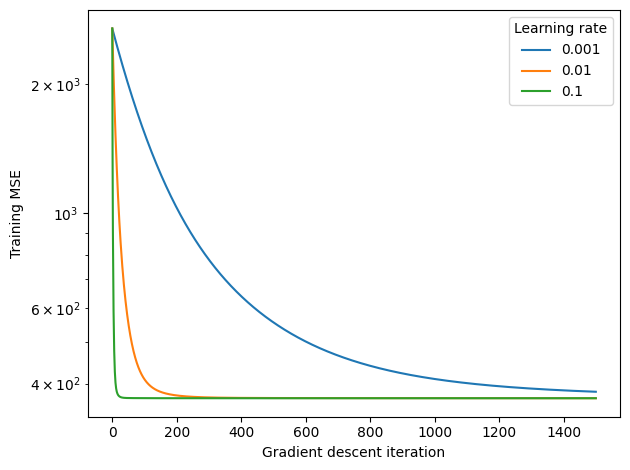

,learning_rate,diverged,train_mse,validation_mse
0,0.001,False,382.627359,328.589846
1,0.010,False,369.633272,328.876116
2,0.100,False,369.558457,328.633471


Selected learning rate: 0.001


In [6]:
learning_rates = [0.001, 0.01, 0.1]
linear_runs, lr_rows = {}, []
for lr in learning_rates:
    run = train_linear(X["train"], y_reg["train"], lr)
    linear_runs[lr] = run
    row = {"learning_rate": lr, "diverged": run["diverged"]}
    for s in ["train", "validation"]:
        pred = linear_predict(X[s], run["w"], run["b"])
        row[s + "_mse"] = (mean_squared_error(y_reg[s], pred)
            if not run["diverged"] and np.isfinite(pred).all() else np.inf)
    lr_rows.append(row)
    plt.plot(run["loss"], label=str(lr))
plt.xlabel("Gradient descent iteration")
plt.ylabel("Training MSE")
plt.yscale("log")
plt.legend(title="Learning rate")
plt.tight_layout()
plt.show()
lr_table = pd.DataFrame(lr_rows)
display(lr_table)
valid_runs = lr_table.loc[~lr_table["diverged"] & np.isfinite(lr_table["validation_mse"])]
if valid_runs.empty:
    raise RuntimeError("All runs failed. Check your gradients and updates.")
best_lr = float(valid_runs.sort_values(["validation_mse", "learning_rate"]).iloc[0]["learning_rate"])
linear = linear_runs[best_lr]
print("Selected learning rate:", best_lr)


## 3. Logistic regression and probability thresholds (20%)
The full implementation below is supplied. Read it, run it, and explain the threshold results. It uses a numerically stable sigmoid and BCE computed from logits. The gradient corresponds to mean BCE. Changing a decision threshold does not rerun this training loop.

,threshold,accuracy,precision,recall,f1
0,0.3,0.846181,0.619241,0.738288,0.673545
1,0.5,0.851736,0.744898,0.471729,0.577646
2,0.7,0.830903,0.797297,0.285945,0.420927


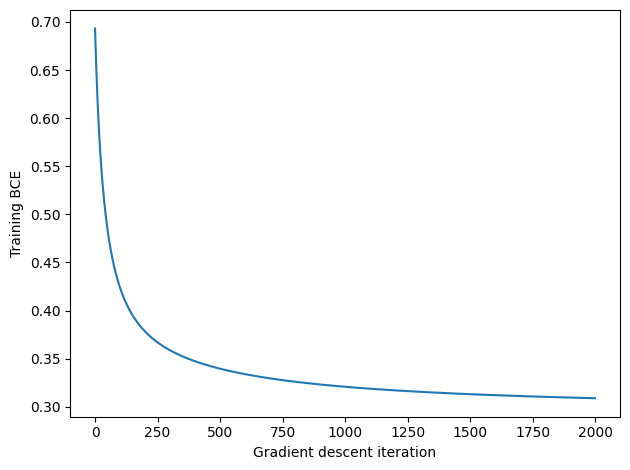

In [7]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    positive = z >= 0
    out[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
    ez = np.exp(z[~positive])
    out[~positive] = ez / (1.0 + ez)
    return out

def train_logistic(X_train, y_train, learning_rate=0.05, steps=2000):
    w, b = np.zeros(X_train.shape[1]), 0.0
    losses = []
    for _ in range(steps):
        z = X_train @ w + b
        losses.append(float(np.mean(np.logaddexp(0, z) - y_train * z)))
        error = sigmoid(z) - y_train
        w -= learning_rate * (X_train.T @ error / len(y_train))
        b -= learning_rate * error.mean()
    return {"w": w, "b": b, "loss": losses}

logistic = train_logistic(X["train"], y_cls["train"])
def logistic_probability(matrix):
    return sigmoid(matrix @ logistic["w"] + logistic["b"])

def classification_metrics(y, probabilities, threshold):
    labels = (probabilities >= threshold).astype(int)
    return {"accuracy": accuracy_score(y, labels),
            "precision": precision_score(y, labels, zero_division=0),
            "recall": recall_score(y, labels, zero_division=0),
            "f1": f1_score(y, labels, zero_division=0)}

logistic_val = logistic_probability(X["validation"])
logistic_threshold_table = pd.DataFrame([
    {"threshold": t, **classification_metrics(y_cls["validation"], logistic_val, t)}
    for t in [0.3, 0.5, 0.7]])
display(logistic_threshold_table)
plt.plot(logistic["loss"])
plt.xlabel("Gradient descent iteration")
plt.ylabel("Training BCE")
plt.tight_layout()
plt.show()


## 4. Required model comparisons (20%)
Ridge uses the same standardized features as linear regression (no polynomial expansion in the required work). The tree uses the unscaled feature matrix. All settings are fixed, so no large hyperparameter search is needed.

In [8]:
ridge = Ridge(alpha=1.0).fit(X["train"], y_reg["train"])
tree = DecisionTreeClassifier(max_depth=5, random_state=SEED).fit(
    X_raw["train"], y_cls["train"])

def regression_prediction(name, split):
    if name == "Linear regression":
        return linear_predict(X[split], linear["w"], linear["b"])
    return ridge.predict(X[split])

def class_probability(name, split):
    if name == "Logistic regression":
        return logistic_probability(X[split])
    positive_col = list(tree.classes_).index(1)
    return tree.predict_proba(X_raw[split])[:, positive_col]

reg_rows, cls_rows = [], []
for name in ["Linear regression", "Ridge"]:
    for s in ["train", "validation"]:
        pred = regression_prediction(name, s)
        reg_rows.append({"model": name, "split": s,
            "mse": mean_squared_error(y_reg[s], pred),
            "mae": mean_absolute_error(y_reg[s], pred)})
for name in ["Logistic regression", "Decision tree"]:
    for s in ["train", "validation"]:
        cls_rows.append({"model": name, "split": s,
            **classification_metrics(y_cls[s], class_probability(name, s), 0.5)})
reg_table = pd.DataFrame(reg_rows)
cls_table = pd.DataFrame(cls_rows)
display(reg_table)
display(cls_table)

threshold_rows = []
for name in ["Logistic regression", "Decision tree"]:
    for t in [0.3, 0.5, 0.7]:
        threshold_rows.append({"model": name, "threshold": t,
            **classification_metrics(y_cls["validation"], class_probability(name, "validation"), t)})
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)
# Stable order resolves ties: linear before Ridge, logistic before tree,
# then 0.3 before 0.5 before 0.7.
selected_reg = reg_table.loc[reg_table["split"].eq("validation")].sort_values(
    "mse", kind="stable").iloc[0]["model"]
selected_cls_row = threshold_table.sort_values("f1", ascending=False, kind="stable").iloc[0]
selected_cls = selected_cls_row["model"]
selected_threshold = float(selected_cls_row["threshold"])
print("Final regression choice:", selected_reg)
print("Final classification choice:", selected_cls, "threshold:", selected_threshold)


,model,split,mse,mae
0,Linear regression,train,382.627359,11.326627
1,Linear regression,validation,328.589846,10.530925
2,Ridge,train,369.558468,10.921902
3,Ridge,validation,328.625833,10.469738


,model,split,accuracy,precision,recall,f1
0,Logistic regression,train,0.861545,0.801587,0.574884,0.669567
1,Logistic regression,validation,0.851736,0.744898,0.471729,0.577646
2,Decision tree,train,0.874653,0.707688,0.828531,0.763356
3,Decision tree,validation,0.835417,0.601116,0.696284,0.645210


,model,threshold,accuracy,precision,recall,f1
0,Logistic regression,0.3,0.846181,0.619241,0.738288,0.673545
1,Logistic regression,0.5,0.851736,0.744898,0.471729,0.577646
2,Logistic regression,0.7,0.830903,0.797297,0.285945,0.420927
3,Decision tree,0.3,0.818750,0.553005,0.817447,0.659713
4,Decision tree,0.5,0.835417,0.601116,0.696284,0.645210
5,Decision tree,0.7,0.834028,0.647799,0.499192,0.563869


Final regression choice: Linear regression
Final classification choice: Logistic regression threshold: 0.3


**Results interpretation**
1. At threshold 0.5 the decision tree has validation F1 0.6452 with logistic regression at 0.5776.
2. The best F1 in the whole validation threshold table is logistic regression at threshold 0.3 with value 0.6735. The decision tree's best is also at 0.3 with value 0.6597. There was no tie so a tie-breaking rule wasn't needed.
3. Final regression model linear regression with learning rate 0.001 was selected because its validation MSE of 328.59 is lower than lr 0.01 (328.8761), lr 0.1 (328.6335) and Ridge (328.6258).

### Optional exploration
Polynomial features and random forests are optional and do not affect access to full credit. If you explore them, insert your cells here, before test evaluation. The required final model-selection code above considers the required models only. Keep optional comparisons on validation data and report them separately.

#### Member 2: regression checks for Q2 (training and validation only)
This cell does not change any model, learning rate or selection. It compares the gradient descent results with the closed-form least-squares solution, and checks the gap between training and validation.

Least squares train MSE: 369.55845673881964
Least squares validation MSE: 328.6334653351144
Largest stable learning rate (2 / max eigenvalue): 0.3684867882210138
Max |Ridge coef - least squares coef|: 0.005502014518980358


,model,split,target_variance,mse,r2,negative_predictions
0,Linear regression,train,1836.998263,382.627359,0.791711,1834
1,Ridge,train,1836.998263,369.558468,0.798825,995
2,Linear regression,validation,1440.736863,328.589846,0.771929,493
3,Ridge,validation,1440.736863,328.625833,0.771904,274


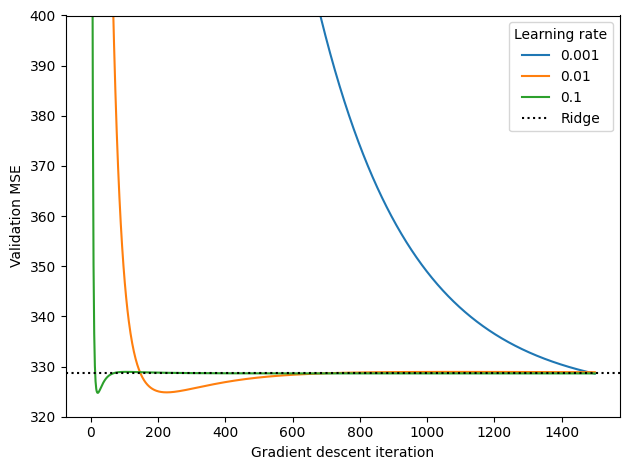

In [9]:
# Member 2: extra checks for Q2 (train and validation only, no model choice is changed here)
X_train_b = np.column_stack([X["train"], np.ones(len(X["train"]))])         # add a column of 1s for the bias
theta_ls = np.linalg.lstsq(X_train_b, y_reg["train"], rcond=None)[0]         # closed-form least squares solution
w_ls, b_ls = theta_ls[:-1], theta_ls[-1]
eig_vals = np.linalg.eigvalsh(2 / len(X_train_b) * X_train_b.T @ X_train_b)  # eigenvalues of the MSE Hessian

print("Least squares train MSE:", mean_squared_error(y_reg["train"], linear_predict(X["train"], w_ls, b_ls)))
print("Least squares validation MSE:", mean_squared_error(y_reg["validation"], linear_predict(X["validation"], w_ls, b_ls)))
print("Largest stable learning rate (2 / max eigenvalue):", 2 / eig_vals.max())   # larger rates would diverge
print("Max |Ridge coef - least squares coef|:", np.abs(ridge.coef_ - w_ls).max())  # how much alpha = 1.0 shrinks

gap_rows = []
for split in ["train", "validation"]:
    for model in ["Linear regression", "Ridge"]:
        y_pred = regression_prediction(model, split)
        mse = mean_squared_error(y_reg[split], y_pred)
        gap_rows.append({"model": model, "split": split,
                         "target_variance": y_reg[split].var(),               # spread of the true rentals in this split
                         "mse": mse,
                         "r2": 1 - mse / y_reg[split].var(),                  # MSE relative to the target variance
                         "negative_predictions": int((y_pred < 0).sum())})    # rentals cannot be negative
gap_table = pd.DataFrame(gap_rows)
display(gap_table)

# Validation MSE during training, same start (zeros) and same updates as train_linear
for lr in learning_rates:
    w, b = np.zeros(X["train"].shape[1]), 0.0
    val_curve = []
    for step in range(1500):
        grad_w, grad_b = linear_gradients(X["train"], y_reg["train"], w, b)
        w, b = gradient_step(w, b, grad_w, grad_b, lr)
        val_curve.append(mse_loss(y_reg["validation"], linear_predict(X["validation"], w, b)))
    plt.plot(val_curve, label=str(lr))
plt.axhline(mean_squared_error(y_reg["validation"], ridge.predict(X["validation"])),
            color="k", linestyle=":", label="Ridge")                         # Ridge validation MSE for reference
plt.ylim(320, 400)
plt.xlabel("Gradient descent iteration")
plt.ylabel("Validation MSE")
plt.legend(title="Learning rate")
plt.tight_layout()
plt.show()


**Member 4 - decision tree interpretation (train and validation only, no model choice changed)**

,importance
rentals_previous_hour,0.535734
hour,0.203681
rentals_same_hour_previous_day,0.104217
is_weekend,0.045685
rentals_mean_previous_24h,0.031331
day_of_week,0.029578
S02,0.017181
S08,0.014707
S04,0.014287
S05,0.003143


split,train,validation,gap
model,,,
Decision tree,0.763356,0.645210,0.118147
Logistic regression,0.669567,0.577646,0.091921


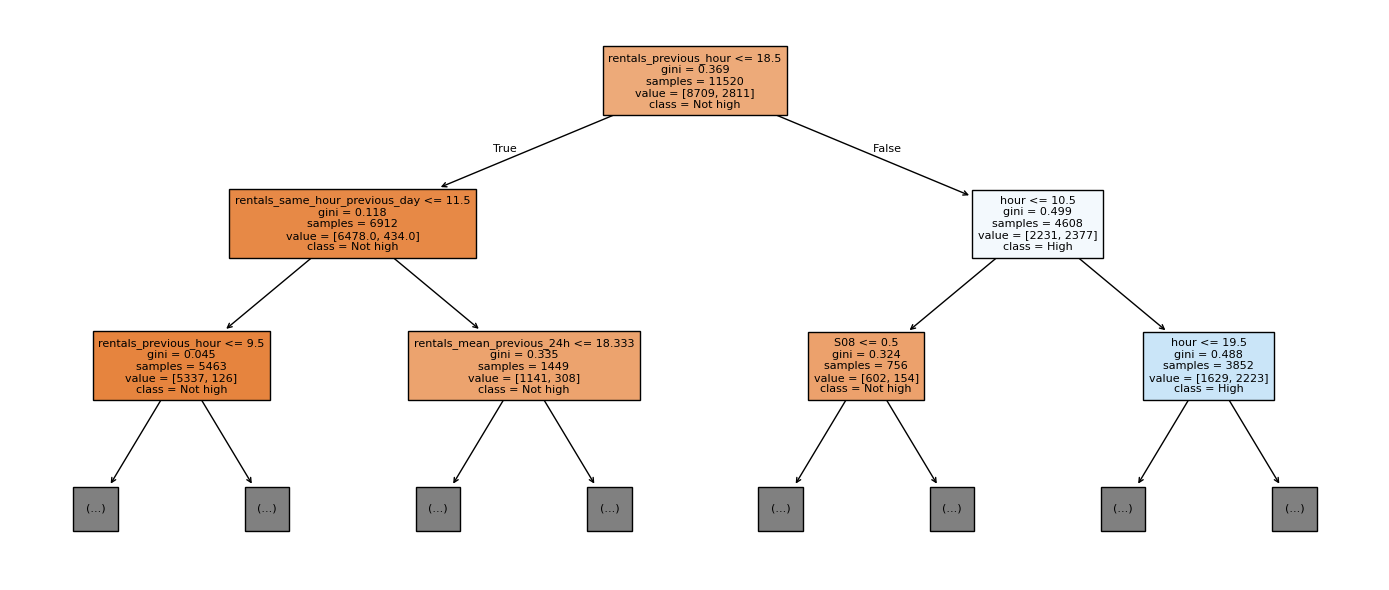

In [10]:
from sklearn.tree import plot_tree
tree_feature_names = numeric_features + station_vocabulary[1:]
tree_importance = pd.Series(tree.feature_importances_, index=tree_feature_names).sort_values(ascending=False)
display(tree_importance.rename("importance").to_frame())

display(cls_table.pivot(index="model", columns="split", values="f1")
        .assign(gap=lambda t: t["train"] - t["validation"]))   # train - validation F1

plt.figure(figsize=(14, 6))
plot_tree(tree, max_depth=2, feature_names=tree_feature_names,
          class_names=["Not high", "High"], filled=True, fontsize=8)
plt.tight_layout()
plt.show()


The tree relies mostly on rentals_previous_hour with importance of 0.536, followed by hour (0.204) and rentals_same_hour_previous_day (0.104). The station indicators contribute only about 0.05. Its first split is rentals_previous_hour <= 18.5, and then hour into ranges <=10.5 and 10.5-19.5, which captures the time-of-day windows. The tree's train-to-validation F1 drop from 0.763 to 0.645 is larger than logistic regression's (0.67 to 0.578), suggesting mild overfitting at depth 5, although the tree still has the higher F1. This is also related to the Q4 case where the previous hour was just below the tree's root split, pushing the prediction for the following (peak) hour to "not high".

## 5. Final test evaluation
Run this section only after all validation-based choices are fixed. Keep the trained models and selected threshold fixed. Do not tune again after viewing test results. Earlier completed test hours may supply lagged observations for later forecasts because this is rolling one-hour-ahead evaluation.

,model,mse,mae
0,Linear regression,293.301122,10.475555


,model,threshold,accuracy,precision,recall,f1
0,Logistic regression,0.3,0.859028,0.686659,0.78903,0.734293


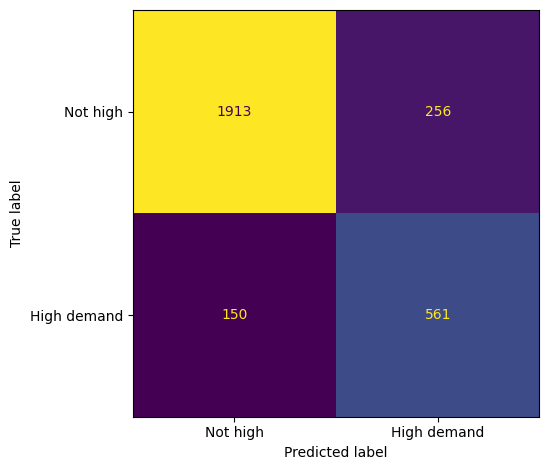

Large regression errors (choose one case to discuss):


,station_name,forecast_time,target_rentals_next_hour,target_high_demand,predicted_rentals,absolute_error,probability_high,predicted_high_demand
1784,MRT Gongguan Station (Exit 2),2025-11-25 07:00:00+08:00,194,1,59.007095,134.992905,0.038805,0
632,MRT Gongguan Station (Exit 2),2025-11-19 07:00:00+08:00,178,1,63.486739,114.513261,0.199957,0
672,MRT Gongguan Station (Exit 2),2025-11-19 12:00:00+08:00,199,1,86.290362,112.709638,0.471987,1
1634,NTU First Student Activity Center (Southwest),2025-11-24 12:00:00+08:00,151,1,51.063469,99.936531,0.456582,1
1785,MRT Gongguan Station (Exit 3),2025-11-25 07:00:00+08:00,117,1,19.840963,97.159037,0.012172,0


Classification errors:


,station_name,forecast_time,target_rentals_next_hour,target_high_demand,predicted_rentals,absolute_error,probability_high,predicted_high_demand
90,NTU First Student Activity Center (Southwest),2025-11-16 11:00:00+08:00,56,1,34.298179,21.701821,0.068668,0
93,NTU Main Library (Southwest),2025-11-16 11:00:00+08:00,25,1,15.674659,9.325341,0.155913,0
95,NTU College of Management Building 1,2025-11-16 11:00:00+08:00,14,1,-2.350661,16.350661,0.063484,0
99,NTU Xiaofu Building (East),2025-11-16 12:00:00+08:00,43,1,21.245232,21.754768,0.114946,0
101,NTU Main Library (Southwest),2025-11-16 12:00:00+08:00,18,1,21.629774,3.629774,0.237211,0


In [11]:
reg_test = regression_prediction(selected_reg, "test")
cls_test_probability = class_probability(selected_cls, "test")
cls_test_labels = (cls_test_probability >= selected_threshold).astype(int)
display(pd.DataFrame([{"model": selected_reg,
    "mse": mean_squared_error(y_reg["test"], reg_test),
    "mae": mean_absolute_error(y_reg["test"], reg_test)}]))
display(pd.DataFrame([{"model": selected_cls, "threshold": selected_threshold,
    **classification_metrics(y_cls["test"], cls_test_probability, selected_threshold)}]))
ConfusionMatrixDisplay.from_predictions(y_cls["test"], cls_test_labels,
    labels=[0, 1], display_labels=["Not high", "High demand"], colorbar=False)
plt.tight_layout()
plt.show()

cases = parts["test"][["station_name", "forecast_time", "target_rentals_next_hour",
                       "target_high_demand"]].copy()
cases["predicted_rentals"] = reg_test
cases["absolute_error"] = np.abs(y_reg["test"] - reg_test)
cases["probability_high"] = cls_test_probability
cases["predicted_high_demand"] = cls_test_labels
print("Large regression errors (choose one case to discuss):")
display(cases.sort_values("absolute_error", ascending=False).head(5))
print("Classification errors:")
display(cases.loc[cases["predicted_high_demand"] != cases["target_high_demand"]].head(5))


**Test results**
- Regression: MSE 293.3, MAE 10.48
- Classification: accuracy 0.859, precision 0.687, recall 0.789, F1 0.734, plus the confusion matrix.

## 6. Four short answers (15%, including contribution statement)
Write about 3–5 English sentences per question. Cite your own results. Do not copy a generic explanation without connecting it to this experiment.

**Q1. Data and leakage.** Why is the split chronological, and why does standardization use training statistics only? Identify one supplied column that would leak target information.

**Answer:** The dataset uses a chronological split (Training: Sept 1–Oct 31, 11,520 model-ready rows; Validation: Nov 1–15, 2,880 rows; Test: Nov 16–30, 2,880 rows) because rental demand is an operational time-series process where forecasts must rely exclusively on historical observations. Shuffling or random splitting would violate temporal causality by allowing past predictions to train on future observations. Standardization must compute statistics (mean and standard deviation) on training rows only (where maximum absolute training feature mean is ~3.25e-15 after centering) so that future distribution parameters, such as seasonal demand shifts or weather events in November, do not leak into feature representations during training. Finally, including the supplied column `high_demand_threshold` (or retrospective flags like `target_zero_assumed`) as a feature would cause direct target leakage because `high_demand_threshold` explicitly defines the station-specific 75th percentile cutoff used to assign the ground-truth `target_high_demand` label.

**Q2. Learning and generalization.** Explain the learning-rate curves. Compare training and validation results for linear regression and Ridge. Do they support an overfitting diagnosis?

**Answer:** A larger learning rate makes the training loss converge much faster. With 0.1, the training MSE reaches the closed-form least-squares value of 369.5585 within a few hundred iterations, while 0.001 is still decreasing after 1,500 iterations and ends at 382.6274; none of the runs diverges because all three rates are below the stability limit of about 0.368. Learning rate 0.001 gives the lowest validation MSE (328.5898, compared with 328.8761 for 0.01 and 328.6335 for 0.1), so we select it, but the margin is only about 0.04 and the validation curve shows that this run has not fully converged. Ridge with alpha = 1.0 gives almost the same result as fully trained linear regression (training MSE 369.5585, validation MSE 328.6258), and we keep Linear Regression because its validation MSE is lower by 0.0360. The results do not support an overfitting diagnosis, because validation MSE is lower than training MSE for both models, R² only changes from 0.7917 to 0.7719 for Linear Regression, and regularization does not improve validation performance; the 493 negative validation predictions suggest that the linear model is more likely to underfit.

**Q3. Classification decisions.** Explain how threshold changes affect precision and recall and whether model parameters change. Compare logistic regression with the tree at threshold 0.5 and justify the final validation-based choice.

**Answer:** When the threshold goes from 0.3 to 0.7, precision increases from 0.6192 to 0.7973, but recall decreases from 0.7383 to 0.2859. Changing the threshold only changes the final class decision, so the learned parameters stay the same. At threshold 0.5, Decision Tree has better F1 than Logistic Regression, 0.6452 compared with 0.5776. For the final choice, we use Logistic Regression with threshold 0.3 because it gives the highest validation F1, which is 0.6735.

**Q4. Failure analysis.** Discuss one test failure using its station, time, actual target, and prediction. Distinguish a possible explanation from verified evidence. Why does rental volume alone not establish a stockout?

**Answer:** Our worst error is S01, MRT Gongguan Station (Exit 2) with forecast time 2025-11-25 07:00 on a Tuesday: the actual target was 194 rentals, but the linear regression predicted 59.0 (error 135), and logistic regression gave a probability of 0.039 so by classifier it is predicted "not high" - a false negative at threshold 0.3. Verified from the data: all three history features were low (previous hour 18, same hour previous Monday 85 and 24-hour mean 72.7), while S01 at 07:00 varies a lot by weekday (178-205 on Nov 19-21, 34-85 on Nov 23-24), because hour enters as one linear term, the model cannot represent a sharp weekday commuter peak.
Possible but unverified explanations include weather, MRT or city events, schedule differences, etc. Lastly, only completed rentals are included, which doesn't demonstrate actual user needs, as availability depends on returns, initial inventory, e-bike charging, malfunctions etc. which are not recorded anywhere, therefore rental volume alone cannot establish a stockout.


## Group contribution statement
Group number: 13

| Name | Student ID | Specific contribution (1–2 sentences) |
|---|---|---|
| 姜明志 | 112701018 | Reviewed and verified the NumPy Linear Regression implementation, ran the learning-rate experiments (0.001, 0.01, 0.1) and the Ridge Regression comparison (alpha = 1.0), selected the regression model using validation MSE and wrote the learning and generalization analysis for Q2 |
| 阮梅日英 | 113550201 | TODO |
| 五惺惺 | 113550202 | Ran and analyzed the Logistic Regression classification experiments, evaluated thresholds 0.3, 0.5, and 0.7 using accuracy, precision, recall, F1-score and wrote the classification decision analysis for Q3 |
| Olga (洛珈) | 115550804 | Decision tree and logistic regression comparison, tree interpretation, final model selection, test evaluation, failure analysis(Q4) and integration. |

Add a row for each member (maximum four). Every member should understand both tasks. Submit one executed notebook with all outputs preserved.

## Source and limitations
Source: [Taipei City YouBike 2.0 Rental Records](https://data.gov.tw/dataset/150635), September–November 2025. See the guide and data dictionary for provenance, feature definitions, and zero-bin assumptions. Observed rentals are not unmet demand or historical bike inventory. No leaderboard or minimum predictive score is used.

## Required environment record
Run the following cell and keep its output in your submitted notebook.

In [12]:
# Required for every submission. Retain this output, even with the recommended versions.
import sys
import subprocess
import importlib.metadata as metadata
print("Python:", sys.version)
for package in ["numpy", "pandas", "matplotlib", "scikit-learn"]:
    print(f"{package}: {metadata.version(package)}")
print("\nFull pip list for this notebook kernel:")
_pip = subprocess.run([sys.executable, "-m", "pip", "list", "--format=freeze", "--disable-pip-version-check"],
                      capture_output=True, text=True)
print(_pip.stdout)
if _pip.returncode:
    print(_pip.stderr)
    raise RuntimeError("Could not record pip list. Resolve this before submission.")


Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
numpy: 2.3.2
pandas: 2.3.2
matplotlib: 3.10.6
scikit-learn: 1.8.0

Full pip list for this notebook kernel:
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.13.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.13.5
bleach==6.3.0
certifi==2025.8.3
cffi==1.17.1
charset-normalizer==3.4.3
click==8.3.2
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cramjam==2.12.1
curl_cffi==0.13.0
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
distro==1.9.0
et_xmlfile==2.0.0
executing==2.2.1
fastapi==0.136.0
fastjsonschema==2.21.2
fastparquet==2026.5.0
fonttools==4.59.2
fqdn==1.5.1
frozendict==2.4.6
fsspec==2026.9.0
greenlet==3.4.0
h11==0.16.0
httpcore==1.0.9
httpie==3.2.4
httptools==0.7.1
httpx==0.28.1
idna==3.10
iniconfig==2.3.0
ipykernel==7.2.0
ipython==9.10.0
ipython_pygments_lexers==1.1.1
ipywidgets==8